# Nigeria Macro Decomposition (2010–2023)

## Key Findings

**1. Oil Dependency**
Industry (oil proxy) contribution to GDP tracks Brent crude price closely —
shrinking from 28% in 2011 to 18% during the 2016 crash, recovering partially
with prices. Nigeria's GDP is effectively a leveraged bet on oil prices.

**2. Growth Without Jobs**
Between 2010 and 2020, GDP nearly doubled in USD terms while unemployment
rose from 3.7% to 5.7%. Non-oil sectors (services, agriculture) grew in
share but did not absorb labour — a structural failure, not a cyclical one.

**3. Data Caveat**
Post-2021 unemployment figures reflect Nigeria's NBS methodology revision
(2022) and are not directly comparable to earlier figures.

## Data Sources
- World Bank: GDP, sectoral composition, unemployment, poverty (wbgapi)
- FRED: Brent Crude spot price (DCOILBRENTEU)
- Period: 2010–2023

In [1]:
import sys
sys.path.append('../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from utils.data_fetcher import fetch_wb, fetch_fred, save_data
import os

print("All imports successful")

All imports successful


In [2]:
INDICATORS = {
    'gdp_usd':          'NY.GDP.MKTP.CD',
    'agric_pct_gdp':    'NV.AGR.TOTL.ZS',
    'industry_pct_gdp': 'NV.IND.TOTL.ZS',
    'services_pct_gdp': 'NV.SRV.TOTL.ZS',
    'unemployment':     'SL.UEM.TOTL.ZS',
    'poverty_rate':     'SI.POV.DDAY',
}

nga_df = fetch_wb(INDICATORS, ['NGA'], 2010, 2023)

print(nga_df.shape)
print(nga_df.head(10))

(14, 8)
  country  year       gdp_usd  agric_pct_gdp  industry_pct_gdp  \
0     NGA  2010  3.669904e+11      23.893704         25.317452   
1     NGA  2011  4.144667e+11      22.234711         28.277800   
2     NGA  2012  4.639710e+11      21.859959         27.073018   
3     NGA  2013  5.201172e+11      20.758623         25.742321   
4     NGA  2014  5.741838e+11      19.990255         24.643609   
5     NGA  2015  4.930267e+11      20.631893         20.160783   
6     NGA  2016  4.046491e+11      20.983110         18.173132   
7     NGA  2017  3.757457e+11      20.846571         22.315117   
8     NGA  2018  4.217393e+11      21.203774         25.733307   
9     NGA  2019  6.682200e+11      25.734931         21.004041   

   services_pct_gdp  unemployment  poverty_rate  
0         50.788844         3.744          38.5  
1         49.243032         3.770           NaN  
2         50.185884         3.761          37.4  
3         52.366601         3.711           NaN  
4         54.15

In [4]:
import os

os.environ['FRED_API_KEY'] = 'fd48e337814710236a4eb138a4f168ad'

In [5]:
brent = fetch_fred({'brent_usd': 'DCOILBRENTEU'}, start='2010-01-01')
brent_annual = brent.resample('YE').mean()
brent_annual.index = brent_annual.index.year
brent_annual = brent_annual.reset_index().rename(columns={'index': 'year'})

print(brent_annual.shape)
print(brent_annual.head(10))

(17, 2)
   year   brent_usd
0  2010   79.609444
1  2011  111.264274
2  2012  111.570683
3  2013  108.555000
4  2014   98.969606
5  2015   52.316549
6  2016   43.638000
7  2017   54.124805
8  2018   71.335000
9  2019   64.300623


In [6]:
nga_merged = nga_df.merge(brent_annual, on='year', how='left')

# Calculate oil contribution proxy — industry % tracks oil closely in Nigeria
nga_merged['non_oil_pct'] = nga_merged['agric_pct_gdp'] + nga_merged['services_pct_gdp']
nga_merged['oil_proxy_pct'] = nga_merged['industry_pct_gdp']

print(nga_merged[['year', 'oil_proxy_pct', 'non_oil_pct', 'brent_usd']].to_string(index=False))

 year  oil_proxy_pct  non_oil_pct  brent_usd
 2010      25.317452    74.682548  79.609444
 2011      28.277800    71.477743 111.264274
 2012      27.073018    72.045843 111.570683
 2013      25.742321    73.125224 108.555000
 2014      24.643609    74.143383  98.969606
 2015      20.160783    78.754115  52.316549
 2016      18.173132    80.768207  43.638000
 2017      22.315117    76.651268  54.124805
 2018      25.733307    73.220825  71.335000
 2019      21.004041    78.632013  64.300623
 2020      18.364996    80.732419  41.957255
 2021      18.253929    80.698881  70.855336
 2022      19.169056    79.726418 100.931310
 2023      19.130238    79.432616  82.493865


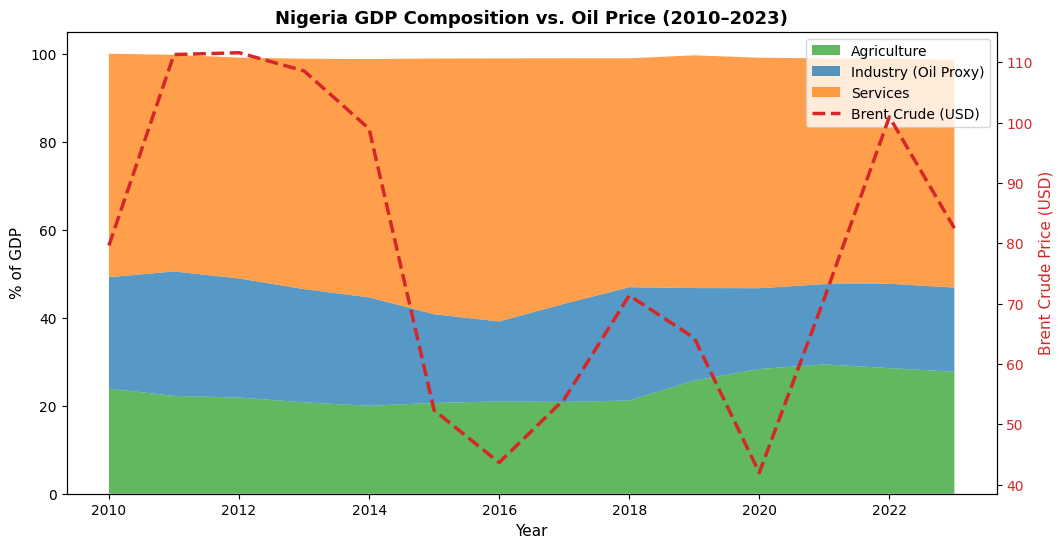

In [7]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.stackplot(nga_merged['year'],
              nga_merged['agric_pct_gdp'],
              nga_merged['oil_proxy_pct'],
              nga_merged['services_pct_gdp'],
              labels=['Agriculture', 'Industry (Oil Proxy)', 'Services'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e'],
              alpha=0.75)

ax2 = ax1.twinx()
ax2.plot(nga_merged['year'], nga_merged['brent_usd'],
         color='#d62728', linewidth=2.5, linestyle='--', label='Brent Crude (USD)')
ax2.set_ylabel('Brent Crude Price (USD)', color='#d62728', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#d62728')

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('% of GDP', fontsize=11)
ax1.set_title("Nigeria GDP Composition vs. Oil Price (2010–2023)",
              fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

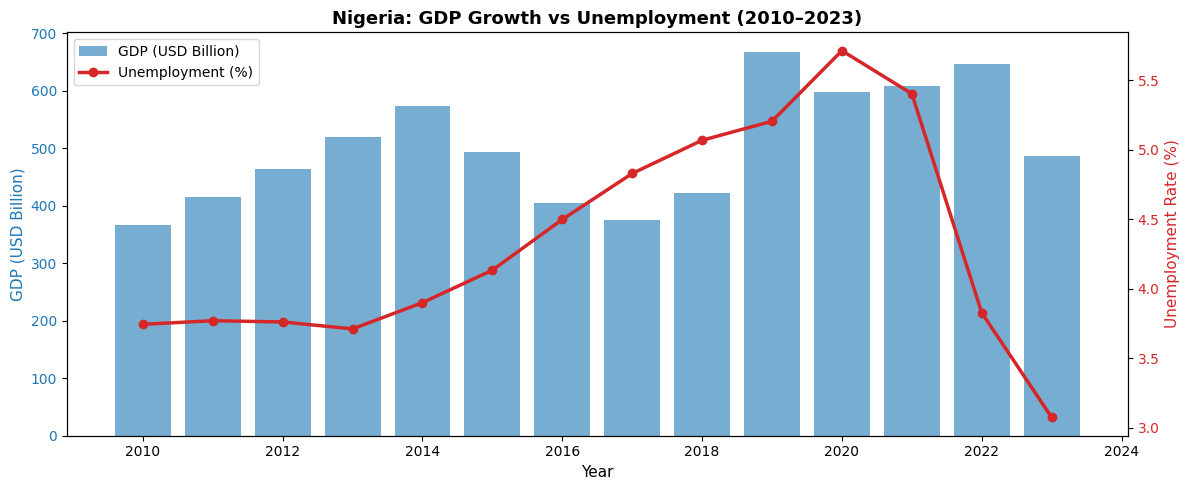

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 5))

color_gdp = '#1f77b4'
color_unemp = '#d62728'

# GDP in billions for readability
nga_merged['gdp_bn'] = nga_merged['gdp_usd'] / 1e9

ax1.bar(nga_merged['year'], nga_merged['gdp_bn'],
        color=color_gdp, alpha=0.6, label='GDP (USD Billion)')
ax1.set_ylabel('GDP (USD Billion)', color=color_gdp, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_gdp)

ax2 = ax1.twinx()
ax2.plot(nga_merged['year'], nga_merged['unemployment'],
         color=color_unemp, linewidth=2.5, marker='o', label='Unemployment (%)')
ax2.set_ylabel('Unemployment Rate (%)', color=color_unemp, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color_unemp)

ax1.set_xlabel('Year', fontsize=11)
ax1.set_title('Nigeria: GDP Growth vs Unemployment (2010–2023)',
              fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/nga_gdp_unemployment.png', dpi=150, bbox_inches='tight')
plt.show()